In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    StandardScaler,
    OneHotEncoder
)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [56]:
df.head()
df.info

<bound method DataFrame.info of     CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0       C00001       6              64          1540        One year   
1       C00002      21             113          1753  Month-to-month   
2       C00003      27              31          1455        Two year   
3       C00004      53              29          7150  Month-to-month   
4       C00005      16             185          1023        One year   
..         ...     ...             ...           ...             ...   
495     C00496      50             128          6970  Month-to-month   
496     C00497       2              49          5917        Two year   
497     C00498      46             198          2158  Month-to-month   
498     C00499       1             185          5755        Two year   
499     C00500      27             181          4292  Month-to-month   

        PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0         Credit Card               No  

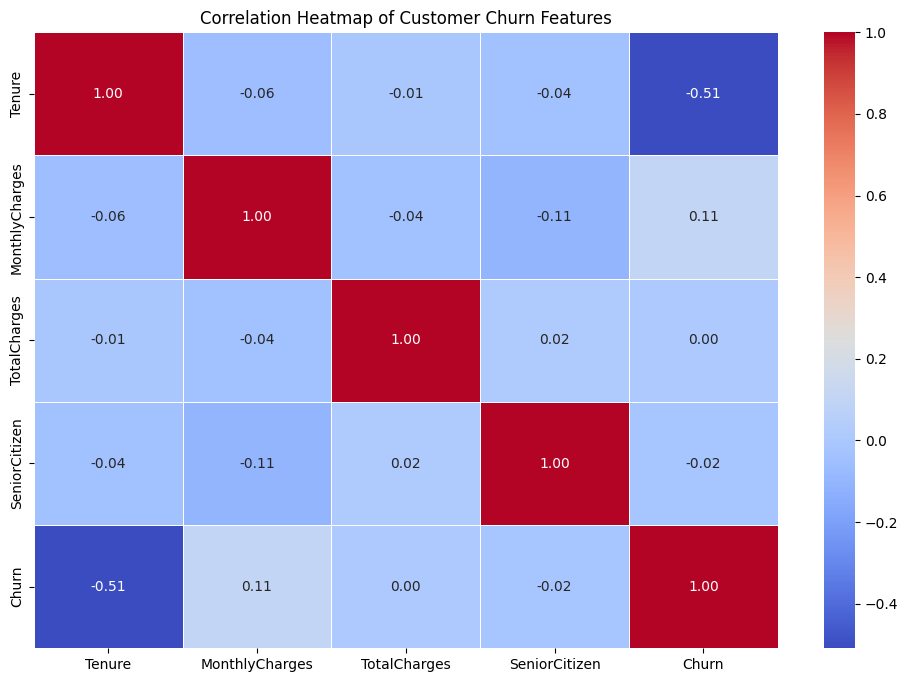

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Customer Churn Features")
plt.show()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


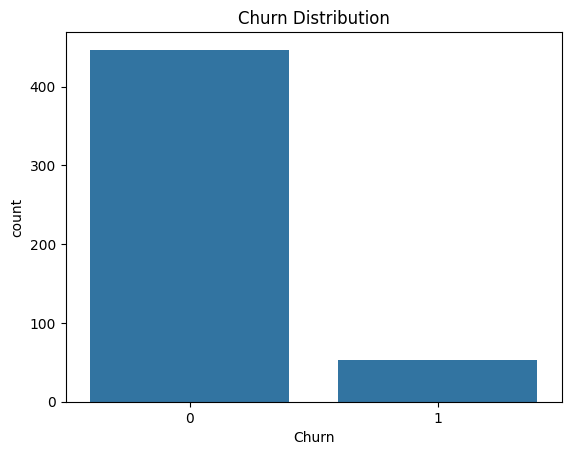

In [8]:
df = pd.read_csv("customer_churn.csv")
df.head()
df.info()
df.describe()
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


In [9]:
df.drop(columns=['CustomerID'], inplace=True)


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

#categorical columns
categorical_cols = ['Contract', 'PaymentMethod', 'PaperlessBilling']



In [12]:
le = LabelEncoder()
df['Contract_Label'] = le.fit_transform(df['Contract'])
df = pd.get_dummies(
    df,
    columns=['PaymentMethod'],
    drop_first=True
)

df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})


In [13]:
mm = MinMaxScaler()
df[['MonthlyCharges_mm', 'TotalCharges_mm']] = mm.fit_transform(
    df[['MonthlyCharges', 'TotalCharges']]
)

ss = StandardScaler()
df['Tenure_ss'] = ss.fit_transform(df[['Tenure']])


In [14]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['MonthlyCharges'] >= Q1 - 1.5 * IQR) &
    (df['MonthlyCharges'] <= Q3 + 1.5 * IQR)
]


In [15]:
# 1. Customer Lifetime Value
df['CLV'] = df['MonthlyCharges'] * df['Tenure']

# 2. Long Term Customer
df['Long_Tenure'] = (df['Tenure'] > 12).astype(int)

# 3. High Spender
df['High_Spender'] = (
    df['MonthlyCharges'] > df['MonthlyCharges'].mean()
).astype(int)

# 4. Average Monthly Cost
df['Avg_Monthly_Cost'] = df['TotalCharges'] / (df['Tenure'] + 1)

# 5. Engagement Score
df['Engagement_Score'] = (
    df['Tenure'] * 0.6 + df['MonthlyCharges'] * 0.4
)


In [16]:
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Tenure                          500 non-null    int64  
 1   MonthlyCharges                  500 non-null    int64  
 2   TotalCharges                    500 non-null    int64  
 3   Contract                        500 non-null    object 
 4   PaperlessBilling                500 non-null    int64  
 5   SeniorCitizen                   500 non-null    int64  
 6   Churn                           0 non-null      float64
 7   Contract_Label                  500 non-null    int64  
 8   PaymentMethod_Credit Card       500 non-null    bool   
 9   PaymentMethod_Electronic Check  500 non-null    bool   
 10  MonthlyCharges_mm               500 non-null    float64
 11  TotalCharges_mm                 500 non-null    float64
 12  Tenure_ss                       500 

,Tenure,MonthlyCharges,TotalCharges,Contract,PaperlessBilling,SeniorCitizen,Churn,Contract_Label,PaymentMethod_Credit Card,PaymentMethod_Electronic Check,MonthlyCharges_mm,TotalCharges_mm,Tenure_ss,CLV,Long_Tenure,High_Spender,Avg_Monthly_Cost,Engagement_Score
0,6,64,1540,One year,0,1,NaN,1,True,False,0.245810,0.176305,-1.478807,384,0,0,220.000000,29.2
1,21,113,1753,Month-to-month,1,1,NaN,0,False,True,0.519553,0.203498,-0.752287,2373,1,0,79.681818,57.8
2,27,31,1455,Two year,0,1,NaN,2,True,False,0.061453,0.165454,-0.461679,837,1,0,51.964286,28.6
3,53,29,7150,Month-to-month,0,1,NaN,0,False,True,0.050279,0.892506,0.797622,1537,1,0,132.407407,43.4
4,16,185,1023,One year,0,1,NaN,1,False,True,0.921788,0.110303,-0.994460,2960,1,1,60.176471,83.6


Train test split

In [31]:
X = df.drop(columns=['Churn', 'Contract'])
y = df['Churn']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])


In [42]:
X['PaperlessBilling'] = X['PaperlessBilling'].map({'Yes': 1, 'No': 0})
import pandas as pd

X = pd.get_dummies(X, columns=['PaymentMethod'], drop_first=True)




In [49]:
pipeline.fit(X_train, y_train)



c:\Users\LOQ\Documents\Internsip\churn_env\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\LOQ\Documents\Internsip\churn_env\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\LOQ\Documents\Internsip\churn_env\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [50]:
y_pred = pipeline.predict(X_test)


In [51]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        89
           1       0.86      0.55      0.67        11

    accuracy                           0.94       100
   macro avg       0.90      0.77      0.82       100
weighted avg       0.94      0.94      0.93       100



In [52]:
pipeline.predict(X_test.head())


array([0, 0, 0, 0, 0])